In [984]:
import numpy as np
import matplotlib.pyplot as plt
import os


def pressure_vdw(r, n, T, l_j_epsilon):
    return n * T / (1 - 2 * n * np.pi * r ** 3 / 3) - 1 * np.pi * r**3 * l_j_epsilon * n**2 / 12

def pressure_vdwa(r, n, T, l_j_epsilon):
    return n * T / (1 - n * np.pi * r ** 3) - 16 * np.pi * r**3 * 4 * l_j_epsilon * n**2 / 3

pressures = []
rs = []
energies = []

for d in os.listdir('.'):
    if os.path.isdir(d) and d[:15] >= '20250902_171000':  # and d[:15] <= '20250902_181400':
        r = float(d.split('r')[-1])
        rs.append(r)
        fs = os.listdir(os.path.join('.', d))
        assert "config.json" in fs and "pressure.npy" in fs, f"Missing files in {d}"
        pressures.append(np.load(os.path.join('.', d, "pressure.npy")))
        energies.append(np.load(os.path.join('.', d, "mean_v2.npy")) * 200 / 3)
Ts = [e[-40:].mean() for e in energies]

In [985]:
[pressures[i].shape[0] for i in range(len(pressures))], rs, Ts

([100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 1000],
 [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.09],
 [0.9999999,
  1.0000098,
  1.0000533,
  1.0002124,
  1.000564,
  1.0013134,
  1.002912,
  1.0054255,
  1.0098455,
  1.0169961,
  1.009804])

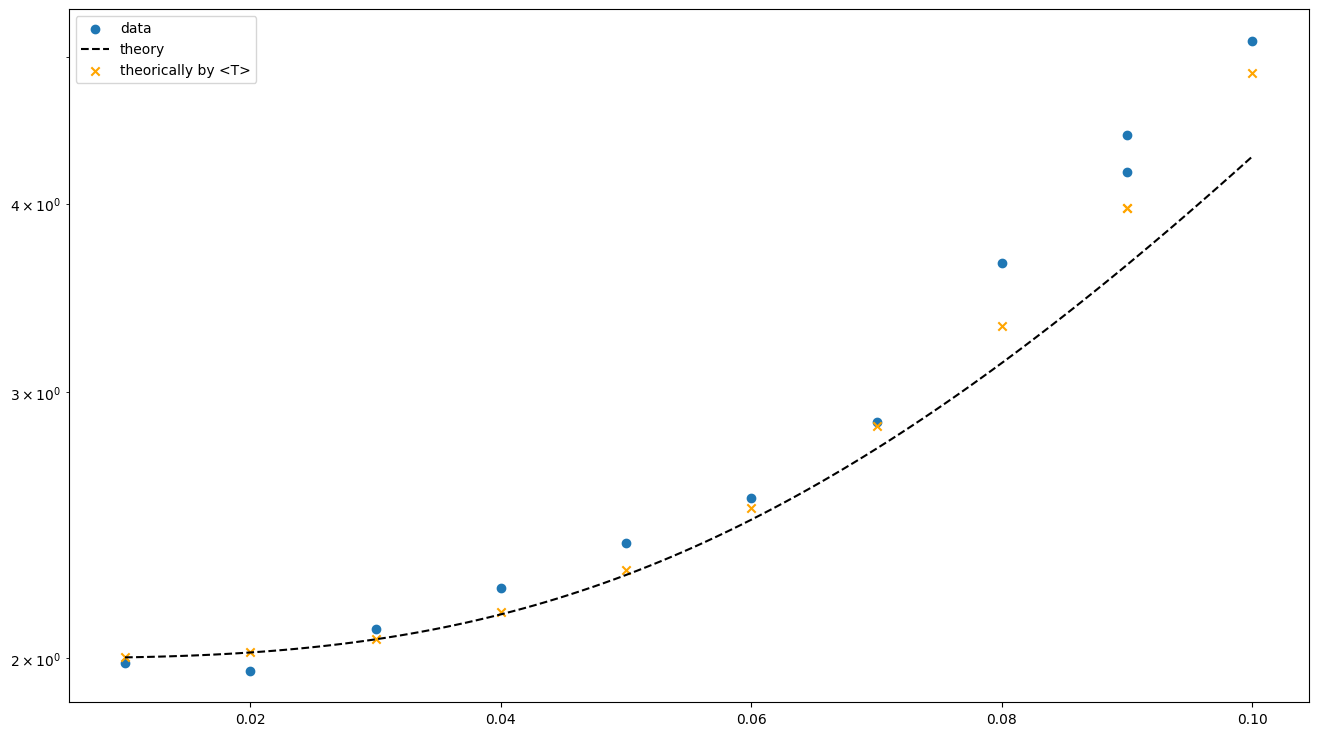

In [986]:
plt.figure(figsize=(16, 9))
plt.scatter(rs,[p[-40:].mean()-30 for p in pressures], label='data')
rss = np.linspace(min(rs), max(rs), 100)
plt.plot(rss, pressure_vdw(rss, 32, 1, 0)-30, label='theory', color='black', linestyle='dashed')
# plt.plot(rss, pressure_vdwa(rss, 32, 1, 0)-30, label='theory a', color='r', linestyle='dashed')
plt.scatter(rs, pressure_vdw(np.array(rs), 32, np.array(Ts), 0)-30, label='theorically by <T>', color='orange', marker='x')
plt.yscale('log')
plt.legend()

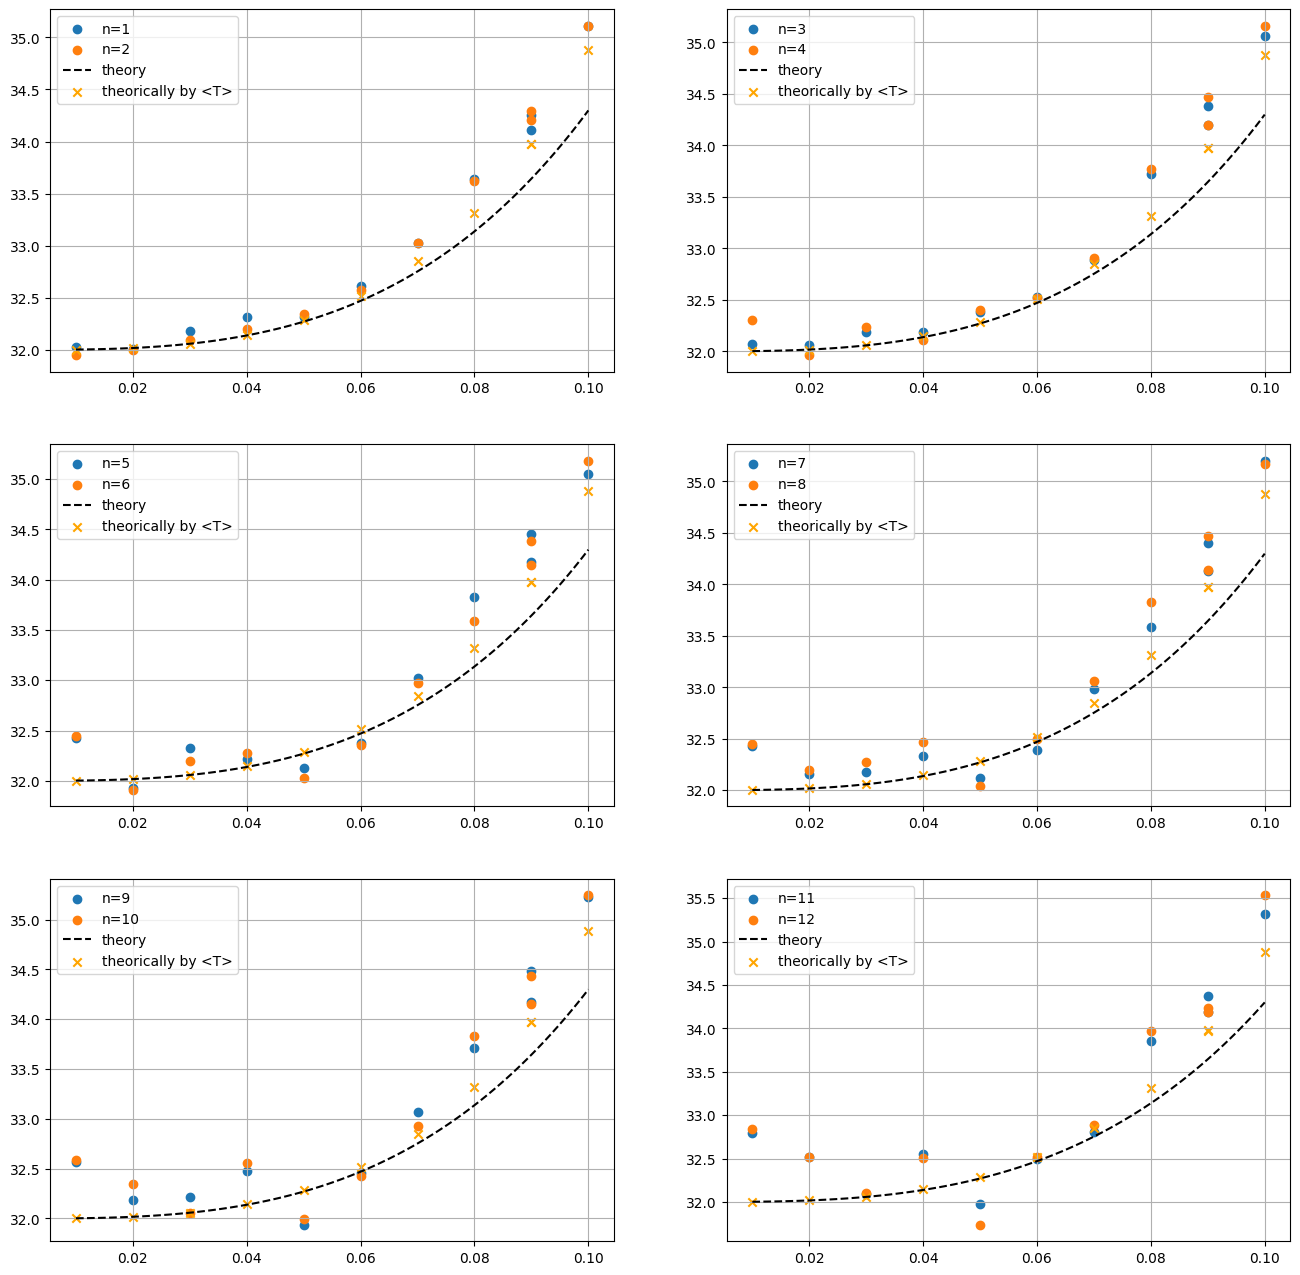

In [987]:
# plt.figure(figsize=(16, 9))
_, ax = plt.subplots(3, 2, figsize=(16, 16))
for n in range(6):
    ax[n//2, n%2].scatter(rs,[p[-int(p.shape[0]/(n*2+1)):].mean() for p in pressures], label=f'n={n*2+1}')
    ax[n//2, n%2].scatter(rs,[p[-int(p.shape[0]/(n*2+2)):].mean() for p in pressures], label=f'n={n*2+2}')
    rss = np.linspace(min(rs), max(rs), 100)
    ax[n//2, n%2].plot(rss, pressure_vdw(rss, 32, 1, 0), label='theory', color='black', linestyle='dashed')
    # ax[n//2, n%2].plot(rss, pressure_vdwa(rss, 32, 1, 0), label='theory a', color='r', linestyle='dashed')
    ax[n//2, n%2].scatter(rs, pressure_vdw(np.array(rs), 32, np.array(Ts), 0), label='theorically by <T>', color='orange', marker='x')
    # ax[n//2, n%2].set_xlim(0, 0.102)
    # ax[n//2, n%2].set_ylim(31, 45)
    ax[n//2, n%2].legend()
    ax[n//2, n%2].grid()
plt.show()

In [988]:
16*32

512

<IPython.core.display.Math object>

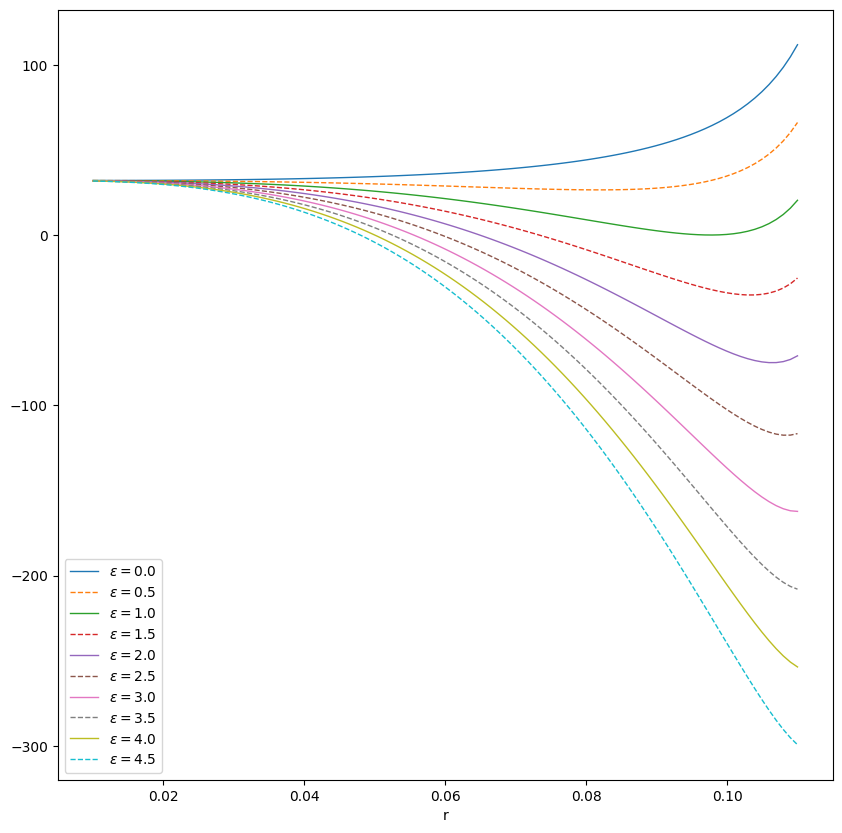

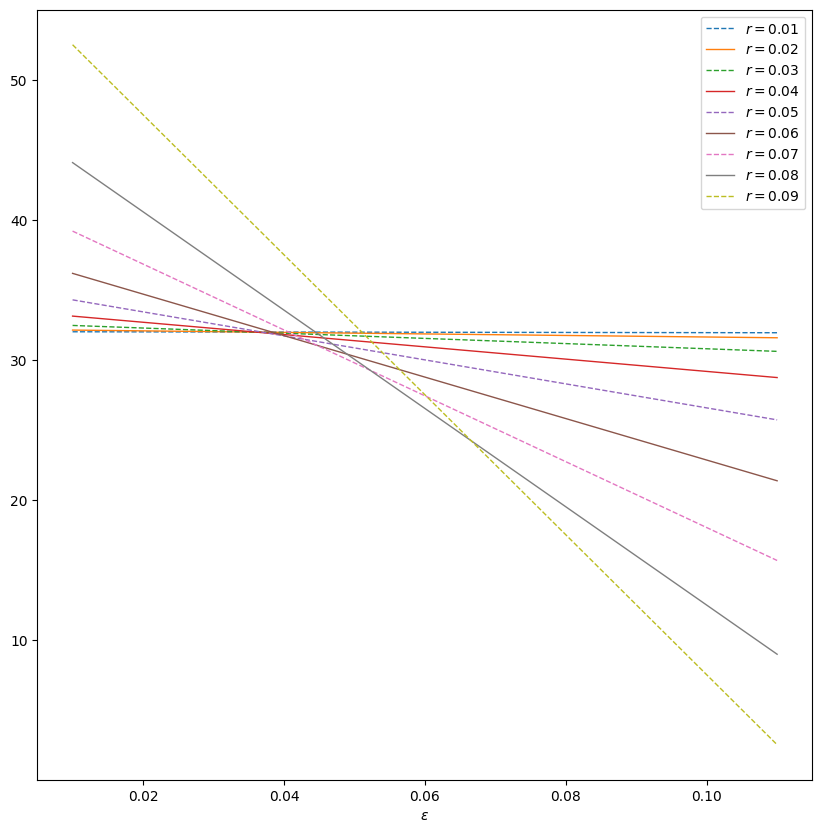

In [999]:
from IPython.display import display, Math

display(Math(r"p = \frac{nT}{1 - 2 n \pi r^3 / 3} - \frac{2 \pi r^3}{3} 4 \epsilon n^2"))

def pressure_vdw(r, n, T, l_j_epsilon):
    return n * T / (1 - 16 * n * np.pi * r**3 / 3) - 16 * np.pi * r**3 * 4 * l_j_epsilon * n**2 / 3
plt.figure(figsize=(10, 10))
rss = np.linspace(0.01, 0.11, 100)
# for l_j_epsilon in [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]:
for l_j_epsilon in np.arange(0, 5, 0.5):
    plt.plot(rss, pressure_vdw(rss, 32, 1, l_j_epsilon), label=f'$\\epsilon={l_j_epsilon}$', linewidth=1, linestyle='--' if int(l_j_epsilon*10)%2==1 else '-')
plt.xlabel('r')
plt.legend()
plt.show()
plt.figure(figsize=(10, 10))
epss = np.linspace(0, 1, 100)
for r in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]:
    plt.plot(rss, pressure_vdw(r, 32, 1, epss), label=f'$r={r}$', linewidth=1, linestyle='--' if int(r*100)%2==1 else '-')
plt.xlabel('$\\epsilon$')
plt.legend()
plt.show()

(1000,)


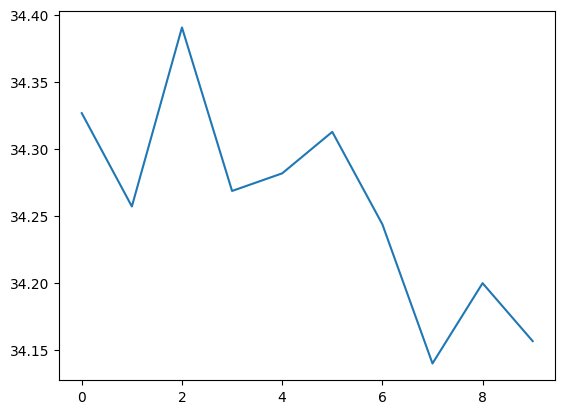

In [990]:
plt.plot(pressures[-1].reshape(-1, 100).mean(axis=1))
print(pressures[-1].shape)

1.0 147898.91418954302


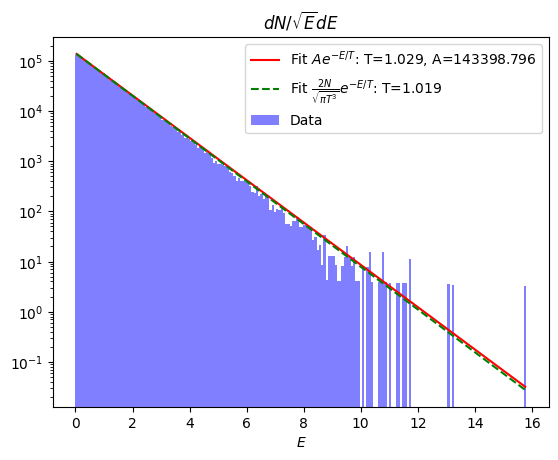

In [991]:
from scipy.optimize import curve_fit
vs = np.load("../output/20250902_171654_304662_779r0.02/velocities.npy")
hist, bins = np.histogram((vs**2).sum(1)*100, bins=200)
bin_widths = np.diff(bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
norm_factor = bin_widths * np.sqrt(bin_centers)
normalized_hist = hist / norm_factor
T0 = 1.0
N = vs.shape[0]
A0 = 2*N/(T0**1.5 * np.sqrt(np.pi))
def exp_func(x, T, A):
    return A * np.exp(-x / T)
def fitT(x, T):
    return 2*N/(T**1.5 * np.sqrt(np.pi)) * np.exp(-x / T)
popt, pcov = curve_fit(exp_func, bin_centers, normalized_hist, [T0, A0])
t, pcovT = curve_fit(fitT, bin_centers, normalized_hist, [T0])
plt.yscale('log')
plt.bar(bin_centers, normalized_hist, width=bin_widths, color='b', alpha=0.5, label='Data')
plt.plot(bin_centers, exp_func(bin_centers, *popt), 'r-', label=f'Fit $Ae^{{-E/T}}$: T={popt[0]:.3f}, A={popt[1]:.3f}')
plt.plot(bin_centers, fitT(bin_centers, *t), 'g--', label=f'Fit $\\frac{{2N}}{{\\sqrt{{\\pi T^3}}}}e^{{-E/T}}$: T={t[0]:.3f}')
plt.legend()
plt.xlabel('$E$')
plt.title('${dN}/{\\sqrt{E}dE}$')
print(T0, A0)

In [992]:
pressure_vdw(0.05, 32, 1, 0)

32.270347430443394

In [993]:
ps = np.load("../output/20250902_171654_304662_779r0.02/pressure.npy")
ps.shape, ps.mean(), ps[-10:].mean()

((100,), 32.010627107354594, 32.34606705862618)

(1000,) 34.96874756669545 34.84329537733474


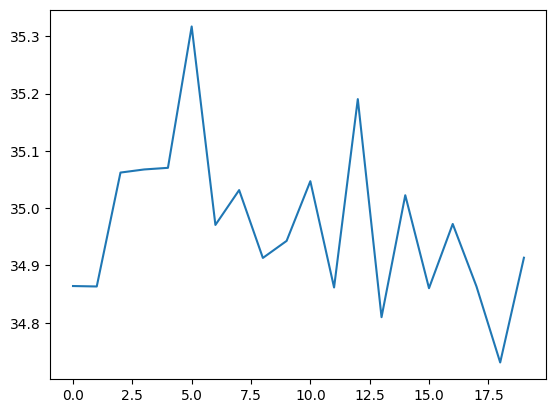

In [994]:
ps = np.load("../output_lj/20250902_191144_207074_216r0.1/pressure.npy")
print(ps.shape, ps.mean(), ps[-10:].mean())
plt.plot(ps.reshape(-1, 50).mean(axis=1))

(100,) 35.13180022093518 35.273456508825326


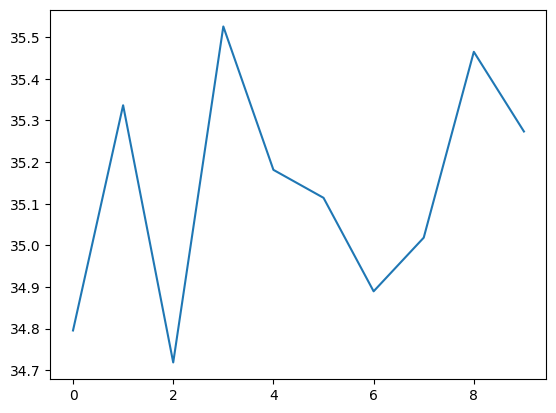

In [998]:
ps = np.load("../output_lj/20250902_194012_310507_929r0.1/pressure.npy")
print(ps.shape, ps.mean(), ps[-10:].mean())
plt.plot(ps.reshape(-1, 10).mean(axis=1))

(1000,) 0.01525257 0.01525454


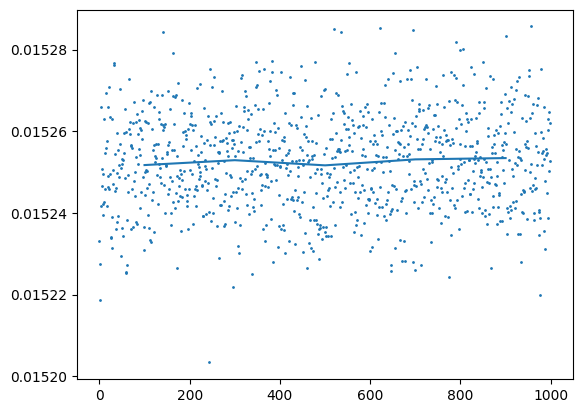

In [995]:
ps = np.load("../output_lj/20250902_191144_207074_216r0.1/mean_v2.npy")
print(ps.shape, ps.mean(), ps[-10:].mean())
plt.scatter(np.arange(ps.shape[0]), ps, s=1)
plt.plot(np.arange(100,ps.shape[0]+100, 200), ps.reshape(-1, 200).mean(axis=1))